# 06. 최종 모델

07에서 고른 설정(지평마다 2026년의 벌점 조합과 매수 기준)으로 분포 모델을 2006–2025년 전체에서 다시 학습하고, 모양은 2009–2025년의 표본 밖 잔차로 맞춰 서비스가 읽을 artifact로 저장한다. 설정은 여기서 바꾸지 않는다.

| 출력 | 계산 | 근거 |
|---|---|---|
| 80% 가격 범위 | 현재가 × exp(10%·90% 분위수) | 07: 폭 σ(x) = HAR + 피처, 모양 = 표본 밖 잔차 |
| 가운데 가격 | 현재가 × exp(50% 분위수) | 07: 중심 μ(x), 절편이 없어 피처가 평균이면 현재가 |
| 상승 확률 | 분포 가운데 현재가보다 위의 비율 | 같은 분포 |
| 구매 신호 | 상승 확률 ≥ 기준이면 구매, ≤ 1 − 기준이면 미루기 | 07: 근거 있는 기준이 없는 지평은 늘 보류 |
| 위험 수준 | 폭 σ의 최근 3년 백분위 | 같은 분포 |

2026년은 **사후 확인** 구간이다. 이미 본 기간이라 미사용 평가셋이 아니다. 진짜 평가는 모델을 동결한 뒤 매일 쌓이는 실시간 예측(`kind='live'`)이다.

In [1]:
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import common
from coffee.config import ARTIFACTS_DIR, HORIZONS
from coffee.evaluate import FIRST_INNER_YEAR, direction_metrics, fold_rows, walk_forward_residuals
from coffee.features import ALL_FEATURES, EXTRA_FEATURES, NEWS_FEATURES, add_news, build_dataset, trading_sessions
from coffee.models import LEVELS, DistributionModel, buy_signal, load_bundle, save_bundle
from coffee.news import load_jev_archive
from coffee.sources import load_sources

data = add_news(build_dataset(load_sources()), load_jev_archive(), mode="research")
chosen = {int(h): v for h, v in common.load_result("distribution_model")["horizons"].items()}
ROW_FEATURES = ALL_FEATURES + EXTRA_FEATURES  # 07과 같은 행
FEATURES = ROW_FEATURES + NEWS_FEATURES
FINAL_YEAR = 2026  # fold_rows(…, 2026): 학습 = 2006–2025, 평가 = 목표일이 확인된 2026년 행
VERSION = "2026-10-06"  # 07 통합 분포 모델 (이전 버전은 git 기록으로 보관)
print(f"자료: {data.index[0]:%Y-%m-%d} ~ {data.index[-1]:%Y-%m-%d}")

자료: 2005-01-03 ~ 2026-10-02


## 1. 2006–2025년으로 다시 학습

In [2]:
models, train_rows = {}, []
for h in HORIZONS:
    c = chosen[h]["final"]
    make = lambda c=c: DistributionModel(FEATURES, FEATURES, True, c["alpha_mean"], c["alpha_scale"])
    # 모양: 2009–2025년을 해마다 그 전까지의 자료로 학습해 낸 표본 밖 표준화 잔차(07과 같은 절차)
    residuals = walk_forward_residuals(data, make, ROW_FEATURES, h, range(FIRST_INNER_YEAR, FINAL_YEAR), FINAL_YEAR - 1)
    fit, _ = fold_rows(data, ROW_FEATURES, h, FINAL_YEAR, FINAL_YEAR)
    models[h] = make().fit(data, fit, data[f"y_{h}"].to_numpy()[fit]).calibrate(residuals)
    train_rows.append({"지평": h, "학습 행": len(fit), "시작": data.index[fit[0]], "끝": data.index[fit[-1]],
                       "모양 잔차 수": len(residuals), "중심 벌점 α_μ": c["alpha_mean"], "폭 벌점 α_σ": c["alpha_scale"],
                       "매수 기준": chosen[h]["threshold"] or "없음"})
pd.DataFrame(train_rows).set_index("지평")

,학습 행,시작,끝,모양 잔차 수,중심 벌점 α_μ,폭 벌점 α_σ,매수 기준
지평,,,,,,,
5,4764,2006-01-03,2025-12-23,4015,10000.0,100000.0,없음
20,4749,2006-01-03,2025-12-02,4000,10000.0,10000.0,0.52
60,4709,2006-01-03,2025-10-06,3960,10000.0,10000.0,없음


## 2. 저장하고 다시 읽기

`model_artifacts/<버전>/distribution`에 지평별 모델과 `metadata.json`을 쓴다. metadata에는 모델 이름(`algorithm`), 피처, 벌점, 매수 기준(없으면 null), 분위, 개발·재사용 확인·2026년 성적(B1 현재가 + HAR 폭, B2 이전 서비스 대비), 학습 구간, 코드 커밋과 파일 해시가 들어간다. 대시보드가 이 값을 읽어 보여 준다. 다시 읽은 모델이 같은 분포를 내는지 확인한다.

In [3]:
target = ARTIFACTS_DIR / VERSION
# 커밋하지 않은 변경이 있으면 '-dirty'가 붙는다. 동결은 생성 코드를 커밋한 뒤 다시 실행해 이 표시가 없게 한다.
commit = subprocess.run(["git", "describe", "--always", "--dirty", "--exclude", "*"], capture_output=True, text=True,
                        cwd=common.ROOT).stdout.strip()


def horizon_meta(h):
    """대시보드가 읽는 지평별 정보: 모델 이름, 피처, 매수 기준, 개발·재사용 확인·2026년 성적."""
    c, model = chosen[h], models[h]
    return {"algorithm": model.describe(), "features": model.features, "threshold": c["threshold"],
            "alpha_mean": c["final"]["alpha_mean"], "alpha_scale": c["final"]["alpha_scale"], "levels": list(LEVELS),
            "shape_rows": int(len(model.shape_)), "dev": c["model"]["dev"], "holdout": c["model"]["holdout"],
            "forward": c["model"]["forward"], "b2": c["b2"],
            "selection": "07: 해마다 안쪽 검증의 평균 CRPS로 벌점을 고름(중첩 검증)"}


save_bundle(target / "distribution", models, {
    "version": VERSION, "train_end": "2025-12-31", "data_end": data.index[-1], "code_commit": commit,
    "kind": "distribution", "algorithm": "분포 모델: 중심 μ(x) + 폭 σ(x) × 모양 Z, CRPS 학습",
    "train_rows": {str(row["지평"]): row["학습 행"] for row in train_rows},
    "horizons": {str(h): horizon_meta(h) for h in HORIZONS},
})
recent = np.arange(len(data) - 250, len(data))
loaded, _ = load_bundle(target / "distribution")
assert all(np.array_equal(loaded[h].quantiles(data, recent), models[h].quantiles(data, recent)) for h in HORIZONS)
{path.relative_to(target).as_posix(): f"{path.stat().st_size / 1024:.0f} KB" for path in sorted(target.rglob("*.*"))}

{'distribution/h20.joblib': '37 KB',
 'distribution/h5.joblib': '37 KB',
 'distribution/h60.joblib': '36 KB',
 'distribution/metadata.json': '19 KB'}

## 3. 2026년 사후 확인

2026년 1월부터 목표일 가격이 확인된 행까지 평가한다. 지평이 길수록 평가 행이 적고, 겹치는 목표 때문에 실제 독립 표본은 더 적다. 개발·재사용 확인 구간 결과와 방향이 같은지만 본다.

In [4]:
rows = []
for h in HORIZONS:
    fit, test = fold_rows(data, ROW_FEATURES, h, FINAL_YEAR, FINAL_YEAR)
    y = data[f"y_{h}"].to_numpy()
    low, mid, high = models[h].quantiles(data, test).T
    t = chosen[h]["threshold"]
    d = direction_metrics(y[test], models[h].prob_up(data, test), base_rate=float(np.mean(y[fit] > 0)),
                          threshold=1.0 if t is None else t)
    rows.append({"지평": h, "평가 행": len(test), "기준일": f"{data.index[test[0]]:%m-%d}~{data.index[test[-1]]:%m-%d}",
                 "80% 범위 적중률": float(np.mean((y[test] >= low) & (y[test] <= high))),
                 "80% 평균 폭(%)": 100 * float(np.mean(np.exp(high) - np.exp(low))),
                 "CRPS": float(models[h].crps(data, test, y[test]).mean()), "AUC": d["auc"], "Brier": d["brier"],
                 "기본 비율 Brier": d["base_brier"], "신호 빈도": d["coverage"], "신호 적중률": d["precision"],
                 "같은 날 늘 구매": d["signal_up_rate"], "실제 상승 비율": d["up_rate"]})
forward = pd.DataFrame(rows).set_index("지평")
forward.round(3)

,평가 행,기준일,80% 범위 적중률,80% 평균 폭(%),CRPS,AUC,Brier,기본 비율 Brier,신호 빈도,신호 적중률,같은 날 늘 구매,실제 상승 비율
지평,,,,,,,,,,,,
5,184,01-02~09-25,0.755,13.506,0.033,0.463,0.251,0.249,0.000,NaN,NaN,0.435
20,169,01-02~09-03,0.615,25.638,0.080,0.515,0.249,0.250,0.515,0.529,0.54,0.479
60,129,01-02~07-09,0.760,36.855,0.083,0.874,0.219,0.250,0.000,NaN,NaN,0.465


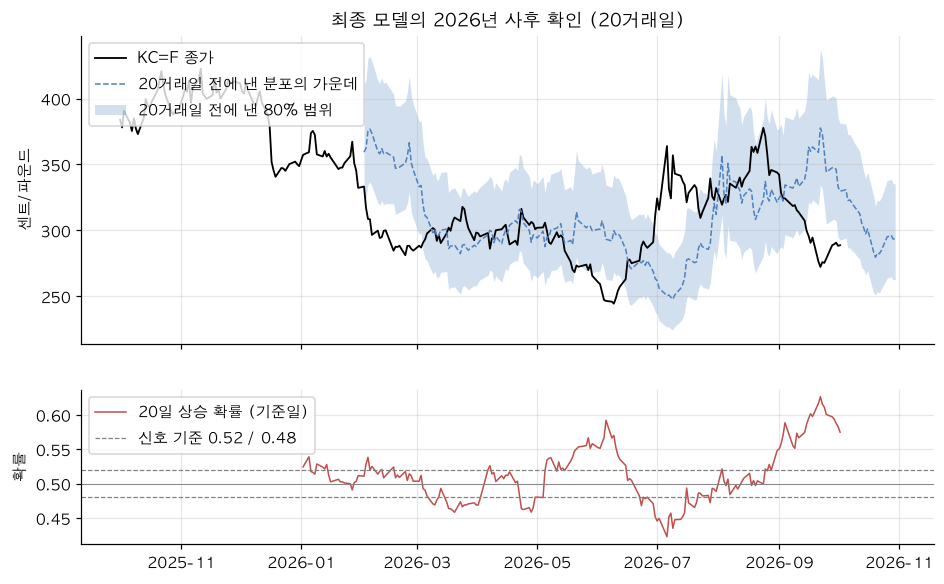

In [5]:
H = 20
origins = np.flatnonzero((data.index >= "2026-01-01") & data["close"].notna().to_numpy())
axis = data.index.append(trading_sessions(data.index[-1] + pd.Timedelta(days=1), data.index[-1] + pd.Timedelta(days=120)))
target_dates = axis[origins + H]
close = data["close"].to_numpy()[origins]
low, mid, high = models[H].quantiles(data, origins).T
prob = models[H].prob_up(data, origins)
threshold = chosen[H]["threshold"]

fig, (top, bottom) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
recent_close = data.loc["2025-10-01":, "close"]
top.plot(recent_close.index, recent_close, color="black", lw=1.2, label="KC=F 종가")
top.plot(target_dates, close * np.exp(mid), color="#4f81bd", lw=1, ls="--", label="20거래일 전에 낸 분포의 가운데")
top.fill_between(target_dates, close * np.exp(low), close * np.exp(high), color="#4f81bd", alpha=0.25, lw=0,
                 label="20거래일 전에 낸 80% 범위")
top.set(ylabel="센트/파운드", title="최종 모델의 2026년 사후 확인 (20거래일)")
top.legend(loc="upper left")
bottom.plot(data.index[origins], prob, color="#c0504d", lw=1, label="20일 상승 확률 (기준일)")
bottom.axhline(0.5, color="gray", lw=0.6)
if threshold is not None:
    bottom.axhline(threshold, color="gray", ls="--", lw=0.8)
    bottom.axhline(1 - threshold, color="gray", ls="--", lw=0.8, label=f"신호 기준 {threshold:.2f} / {1 - threshold:.2f}")
bottom.set(ylabel="확률")
bottom.legend(loc="upper left")
common.save_fig(fig, "final_forecast_2026.png")
plt.show()

2026년 80% 범위 적중률은 5일 76%, 20일 62%, 60일 76%로 목표보다 낮다(이전 모델 2026-10-05는 76 / 62 / 74%). 그림에서 2월 급락, 7월 급등, 9월 하락 때 실제 가격이 범위 밖에 있었다. 범위는 급변을 미리 알려 주지 못하고 급변 뒤에 넓어진다. 상승 확률의 AUC는 0.46 / 0.52 / 0.87이다. 신호를 내는 20일의 신호 적중률은 53%로 같은 날 늘 구매했을 때(54%)보다 낮았다. 60일 AUC는 평가 행 129개가 크게 겹친 한 해의 값이라 판단에 쓰지 않는다.

## 4. 최신 기준일의 예측

서비스가 매일 계산할 값과 같은 방식이다. 예측 변동성은 분포의 표준편차를 연율로 바꾼 값이고, 위험 수준은 최근 3년(756거래일) 동안의 폭 σ 가운데 오늘 값의 백분위다.

In [6]:
origin = len(data) - 1
rows = []
for h in HORIZONS:
    model = models[h]
    low, mid, high = model.quantiles(data, [origin])[0]
    p_up = float(model.prob_up(data, [origin])[0])
    history = np.log(model.distribution(data, np.arange(origin - 755, origin + 1))[1])
    close = data["close"].iloc[origin]
    rows.append({"지평": h, "기준일": data.index[origin], "목표일": axis[origin + h], "현재가": close,
                 "가운데 가격": close * np.exp(mid), "80% 하단": close * np.exp(low), "80% 상단": close * np.exp(high),
                 "상승 확률": p_up, "신호": buy_signal([p_up], chosen[h]["threshold"])[0],
                 "예측 변동성(연율)": float(model.spread(data, [origin])[0] * np.sqrt(252 / h)),
                 "최근 3년 백분위": float((history <= history[-1]).mean()),
                 "결측 피처 수": int(data[model.features].iloc[origin].isna().sum())})
today = pd.DataFrame(rows).set_index("지평")
today.round(3)

,기준일,목표일,현재가,가운데 가격,80% 하단,80% 상단,상승 확률,신호,예측 변동성(연율),최근 3년 백분위,결측 피처 수
지평,,,,,,,,,,,
5,2026-10-02,2026-10-09,288.75,289.218,271.675,310.246,0.513,hold,0.376,0.616,0
20,2026-10-02,2026-10-30,288.75,293.594,262.753,335.588,0.575,buy,0.344,0.276,0
60,2026-10-02,2026-12-29,288.75,292.890,239.435,375.419,0.531,hold,0.355,0.860,0


2026-10-02 기준 80% 범위는 5일 271.7–310.2, 20일 262.8–335.6, 60일 239.4–375.4이고, 가운데 가격은 289.2 / 293.6 / 292.9다(현재가 288.75). 상승 확률은 51 / 57 / 53%로, 기준이 있는 20일만 '매수 추천'이다. 이 신호의 근거는 개발 구간에서 늘 구매보다 0.4%p 높은 적중률뿐이라 약하다. 예측 변동성은 연율 34–38%이고, 60일은 최근 3년 가운데 높은 쪽(86 백분위)이다.

In [7]:
common.save_result("final_model", {
    "version": VERSION, "code_commit": commit, "train": train_rows,
    "forward_2026": forward.round(4).reset_index().to_dict("records"),
    "latest": today.round(4).reset_index().to_dict("records"),
})

## 정리

- 최종 모델: 07의 분포 모델(지평마다 하나), `model_artifacts/2026-10-06/distribution`에 저장했다. 이전 버전(2026-10-05의 수익률·방향·변동성 세 모델)은 커밋 기록에 남긴다.
- 기준선보다 낫다고 할 수 있는 지평은 없다. 화면에 기준선 대비 CRPS와 실제 적중 기록을 함께 보여 준다.
- 생성 코드를 커밋한 뒤 이 노트북을 다시 실행해 metadata의 커밋 표시(`-dirty`)를 바로잡는다. 이후 매일 저장되는 live 예측이 처음으로 보지 않은 자료에 대한 평가다.